# Dependencies

In [1]:
import datetime
import yaml
import numpy as np
import pandas as pd
import pathlib
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt

from src.data.prepare_data import prepare_non_rnn_data, prepare_rnn_data, concatenate_multi_input_data
from src.train.models import build_dmq_v0, build_dmq_v1, build_dmq
from src.train.losses import make_total_tilted_loss, tilted_loss, make_tilted_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score

keras.utils.set_random_seed(1)
# =====================================================================
# Configuration
# =====================================================================
# Load config for defaults
with open("config/config_file.yaml", "r") as f:
    config = yaml.safe_load(f)

BASE_PATH = pathlib.Path('.')
data_config = config['data']
INPUT_FILES = data_config['input_files']
TARGET_FILE = data_config['target_file']
TARGETS_PATH = BASE_PATH/ 'data' / 'processed' / TARGET_FILE
INPUT_PATHS = [BASE_PATH / 'data' / 'processed' / file for file in INPUT_FILES]
START_DATE = data_config['start_date']

# Data configurations
TARGET_IDX = 0  # 0: Infl_yoy, 1: IP_yoy, 2: Unrate_yoy
TIME_STEPS = 12  # Number of quarters for RNN
YEAR = 1997     # Train cutoff year
VAL_MONTHS = 60   # Number of validation years
TEST_MONTHS = 60

QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
EPOCHS = 500
BATCH_SIZE = 4
LEARNING_RATE = 0.001

target_name_dict = {
    0: 'Infl_yoy',
    1: 'IP_yoy',
    2: 'Unrate_yoy',
}

target_name = target_name_dict[TARGET_IDX]
print(f"Experimental framework for target: {target_name}")

Experimental framework for target: Infl_yoy


# Helper functions

In [2]:
def plot_and_evaluate_train_predictions(
        y_pred, 
        y_true,
        multi_quantile=False
):
    
    plt.plot(y_true, label='Actual values')
    if multi_quantile:
        for i in range(y_pred.shape[1]):
            plt.plot(y_pred[:,i], label=f'Predicted Q{i+1} values')
    else:
        plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.show()


def evaluate_quantile_predictions(
        y_pred,
        y_true,
        q_benchmarks,
        mean_benchmark
):
    r1_all = []
    for i,q in enumerate(QUANTILES):

        r1_q = compute_oos_r1_score(
            benchmark_pred=q_benchmarks[:,i],
            y_true=y_true.flatten(),
            y_pred=y_pred[:,i],
            q=q
        )
        r1_all.append(r1_q)
        print(f'R1 for q{q}: {r1_q}')

    print(f'Mean R1: {np.mean(r1_all)}')

    mean_preds = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)

    r2 = compute_oos_r2_score(
        y_true=y_true.flatten(),
        y_pred=mean_preds.flatten(),
        benchmark=mean_benchmark
    )

    print(f'R2 score: {r2}')



# Static data

In [6]:
non_rnn_data = prepare_non_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
)

(
    X_train,
    X_val,
    X_test,
    targets_train,
    targets_val,
    targets_test
) = non_rnn_data

print(targets_train.shape, targets_val.shape, targets_test.shape)

targets_train = targets_train.copy()
targets_val   = targets_val.copy()
targets_test  = targets_test.copy()

X_train_full = pd.concat([X_train, X_val])
targets_train_full = pd.concat([targets_train, targets_val])
y_train = targets_train[target_name]
y_train_full = targets_train_full[target_name]
y_val = targets_val[target_name]
y_test = targets_test[target_name]
mq_y_train_full = np.repeat(y_train_full.values.reshape(-1,1), 5, axis=1)
mq_y_val = np.repeat(y_val.values.reshape(-1,1), 5, axis=1)

(384, 3) (60, 3) (60, 3)


In [22]:
[X.shape for X in X_train_full]

[(444, 15),
 (444, 31),
 (444, 10),
 (444, 8),
 (444, 13),
 (444, 21),
 (444, 20),
 (444, 4)]

## Inspect data

In [4]:
from statsmodels.tsa.stattools import adfuller

targets = pd.concat([targets_train, targets_val, targets_test])

In [5]:
targets

,Infl_yoy,IP_yoy,Unrate_yoy
date,,,
1961-01-01,1.587603,-8.832737,23.841102
1961-02-01,1.451502,-8.060415,36.290549
1961-03-01,1.451502,-6.551866,24.512246
1961-04-01,0.909863,-3.721446,29.725152
1961-05-01,0.908944,-2.078615,33.085424
...,...,...,...
2002-08-01,1.732371,1.530708,15.123097
2002-09-01,1.504626,2.123361,13.102826
2002-10-01,2.006756,2.189399,7.275935


<Axes: xlabel='date'>

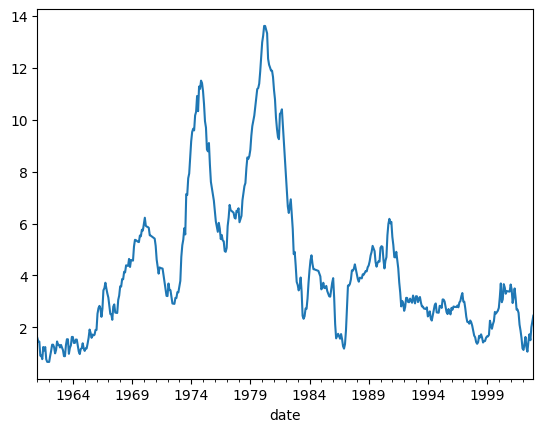

In [6]:
targets['Infl_yoy'].plot()

In [7]:
results = adfuller(targets['Infl_yoy'])
print(f'p-value: {results[1]}')

p-value: 0.056022008899130296


<Axes: xlabel='date'>

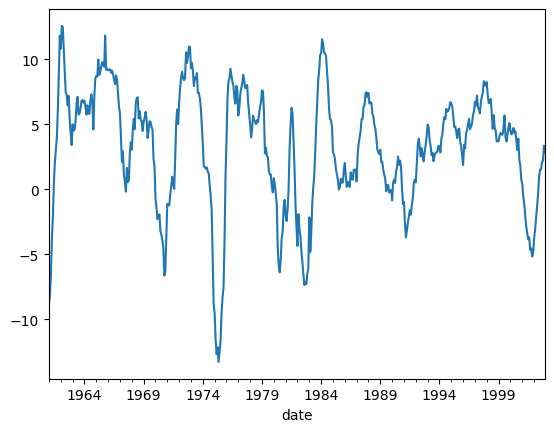

In [8]:
targets['IP_yoy'].plot()

In [9]:
results = adfuller(targets['IP_yoy'])
print(f'p-value: {results[1]}')

p-value: 4.971055701128377e-05


<Axes: xlabel='date'>

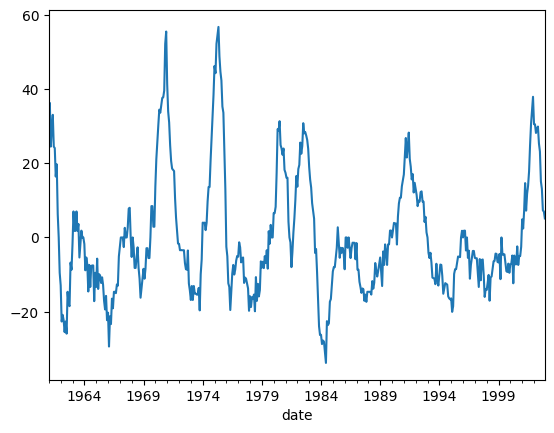

In [10]:
targets['Unrate_yoy'].plot()

# Baselines

## Benchmarks

In [7]:
benchmark_dict = {
    0: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Infl_yoy.csv',
    1: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_IP_yoy.csv',
    2: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Unrate_yoy.csv'
}

benchmarks = pd.read_csv(benchmark_dict[TARGET_IDX], index_col=0, parse_dates=True)
benchmarks.head()

,Naive_Q5,Naive_Q25,Naive_Q50,Naive_Q75,Naive_Q95,Naive_Mean,IAR_Q5,IAR_Q25,IAR_Q50,IAR_Q75,IAR_Q95
1998-01-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.361970,3.756464,5.147799,6.256978,7.765424
1998-02-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.484558,3.732758,5.124497,6.587725,7.953568
1998-03-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.680255,3.730914,4.970536,6.832331,8.255991
1998-04-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.763296,3.587599,4.684487,6.892354,8.381262
1998-05-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.674143,3.754978,5.074781,6.986625,8.243524


In [8]:
naive_preds = benchmarks.loc[X_test.index, 'Naive_Q5': 'Naive_Q95']
naive_mean =  benchmarks.loc[X_test.index, 'Naive_Mean']

evaluate_quantile_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

R1 for q0.05: 0.0
R1 for q0.25: 0.0
R1 for q0.5: 0.0
R1 for q0.75: 0.0
R1 for q0.95: 0.0
Mean R1: 0.0
R2 score: -10.62080249083579


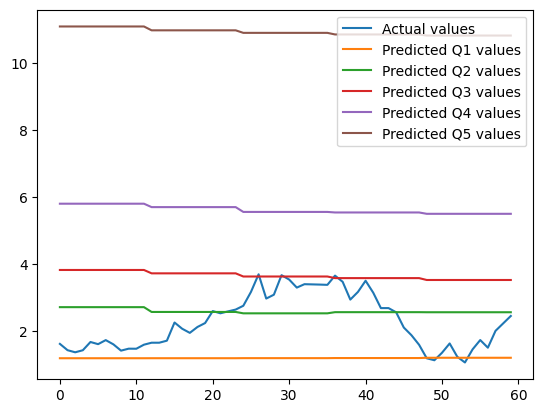

In [8]:
plot_and_evaluate_train_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

In [9]:
benchmarks.columns = benchmarks.columns.str.replace(
    r'VG|IAR|UAR',
    'LIT',
    regex=True
)
lit_preds = benchmarks.loc[X_test.index, 'LIT_Q5': 'LIT_Q95']
evaluate_quantile_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)


R1 for q0.05: -493.11783332630637
R1 for q0.25: -25.320355126404937
R1 for q0.5: -7.682704396379125
R1 for q0.75: 6.980225155621045
R1 for q0.95: 56.538006995660695
Mean R1: -92.52053213956174
R2 score: 25.41613373206192


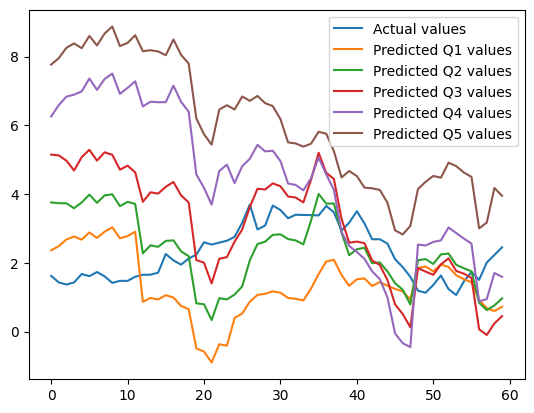

In [10]:
plot_and_evaluate_train_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

## Check training loss at init for a network that predicts the median

In [9]:
quantile = 0.5
subsample_size = X_train_full.shape[0]
learning_rate = 1e-5

for quantile in [0.05, 0.25, 0.5, 0.75, 0.95]:
    model_1 = keras.Sequential(
        [
            keras.layers.Dense(
                32,
                kernel_initializer='zeros',
                bias_initializer='zeros'
            ),
            keras.layers.Dense(
                1, 
                bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
            )
        ]
    )
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate), 
        loss=make_tilted_loss(quantile)
    )

    history = model_1.fit(
        x=X_train_full.values[:subsample_size],
        y=y_train_full.values[:subsample_size],
        epochs=1, 
        batch_size=4,
        validation_data=(X_val, y_val),
        # callbacks=[
        #     keras.callbacks.EarlyStopping(
        #         monitor='val_loss',
        #         min_delta=1e-4,
        #         patience=20,
        #         restore_best_weights=False
        #     )
        # ]
    )

    # Training loss at init should be 
    y_train_full_tf = tf.constant(y_train_full.values)
    y_mean_tf = tf.constant(y_train_full.quantile(quantile))
    expected_loss = tilted_loss(y_train_full_tf, y_mean_tf, q=quantile)

    print(
        (f'Initial loss: {np.round(history.history['loss'][0],4)}. '
        f'Expected: {np.round(expected_loss, 4)}')
    )

# plt.plot(history.history['loss'], label='Training loss')
# plt.plot(history.history['val_loss'], label='Validation loss')
# plt.legend()
# plt.show()

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1798 - val_loss: 0.0748
Initial loss: 0.1798. Expected: 0.1804
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7130 - val_loss: 0.1283
Initial loss: 0.713. Expected: 0.7156
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0627 - val_loss: 0.5413
Initial loss: 1.0627. Expected: 1.0684
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0366 - val_loss: 0.7665
Initial loss: 1.0366. Expected: 1.0418
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3761 - val_loss: 0.4179
Initial loss: 0.3761. Expected: 0.3776


Loss works, we can move on. Note that to check the initial loss the kernel must be initialized as zero.

## Overfit on a small number of examples

In [44]:
quantile = 0.5
subsample_size = 10
lr=3e-4
model = keras.Sequential(
    [
        keras.layers.Dense(
            512,
            activation='relu'
        ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     128, 
        #     activation=activation,
        # ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     64, 
        #     activation=activation,
        # ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     32, 
        #     activation='relu',
        # ),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_full.values[:subsample_size],
    y=y_train_full.values[:subsample_size],
    epochs=100, 
    batch_size=8,
    validation_data=(X_val, y_val),
    # callbacks=[
    #     EarlyStopping(
    #         min_delta=1e-4,
    #         patience=20
    #     )
    # ]
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

y_pred = model.predict(X_train_full[:subsample_size])
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_full.values.flatten()[:subsample_size]
    )

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 1.5537 - val_loss: 0.5030
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.3129 - val_loss: 0.4700
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 1.1102 - val_loss: 0.4370
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.9143 - val_loss: 0.4131
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.7487 - val_loss: 0.3928
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.6436 - val_loss: 0.3780
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5216 - val_loss: 0.3675
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.4050 - val_loss: 0.3658
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3047 - val_loss: 0.3647
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2450 - val_loss: 0.3628
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2293 - val_loss: 0.3621
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1919 - val_l

KeyboardInterrupt: 

## Overfit on the whole training sample

In [ ]:
quantile = 0.5
lr = 3e-4
model = keras.Sequential(
    [
        keras.layers.Dense(
            512, 
            activation='relu'
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            256, 
            activation='relu',
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            128, 
            activation='relu',
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            64, 
            activation='relu',
        ),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train.values,
    y=y_train.values,
    epochs=100, 
    batch_size=8,
    validation_data=(X_val, y_val),
    # callbacks=[
    #     EarlyStopping(
    #         min_delta=1e-4,
    #         patience=20
    #     )
    # ]
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

y_pred = model.predict(X_train)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

## Generalize

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 5e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            32, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            16, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train.values,
    y=y_train.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(
            min_delta=1e-3,
            patience=5
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_train)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

Notes:
- Need to train feed-forward models with shuffle set to True for generalization
- I think selecting a random subset of training data for validation with a 
    buffer (reserving the last data for training) improves generalization
- l2 needs to be between (8e-1, 9e-1) (9e-1 is too much) 8e-1 is good

### Train on augmented data (jitter)

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            32, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            16, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(
            min_delta=1e-3,
            patience=5
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Augment the validation data as well for a larger validation set

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Make a larger validation set

In [ ]:
X_val_aug_l.shape

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug_l, y_val_aug_l),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Even larger augmentation

In [ ]:
# Shift up
X_train_shift_up = add_noise(X_train, loc=0.05)
X_train_shift_down = add_noise(X_train, loc=-0.05)

X_train_aug_2 = pd.concat([X_train_shift_up, X_train_shift_down, X_train_aug], ignore_index=True)
y_train_aug_2 = pd.concat([y_train, y_train, y_train_aug], ignore_index=True)

X_train_aug_2.shape, y_train_aug_2.shape

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug_2.values,
    y=y_train_aug_2.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug_2)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug_2.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Sample from low inflation period

In [ ]:
X_train_aug = pd.concat(
    [
        add_noise(X_train[-120:]),
        add_noise(X_train[-120:]),
        X_train
    ],
    ignore_index=True
)
y_train_aug = pd.concat([y_train[-120:]]*2 + [y_train], ignore_index=True)

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug_2)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug_2.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

# RNN data

In [10]:
import json

with open('data/fred_group_dict.json', 'r') as f:
    fred_group_dict = json.load(f)

fred_groups = list(fred_group_dict.values())

In [11]:
rnn_data = prepare_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
    n_timesteps=12,
    split_groups=fred_groups
)

(
    X_train_rnn,
    X_val_rnn,
    X_test_rnn,
    targets_train_rnn,
    targets_val_rnn,
    targets_test_rnn
) = rnn_data

if not isinstance(X_train_rnn, list):
    print(X_train_rnn.shape, X_val_rnn.shape, X_test_rnn.shape)
else:
    print([X.shape for X in X_train_rnn])
    print([X.shape for X in X_val_rnn])
    print([X.shape for X in X_test_rnn])

print(targets_train_rnn.shape, targets_val_rnn.shape, targets_test_rnn.shape)

# Create single target vector
y_train_rnn = targets_train_rnn[:,TARGET_IDX]
y_val_rnn = targets_val_rnn[:,TARGET_IDX]
y_test_rnn = targets_test_rnn[:, TARGET_IDX]

mq_y_train_rnn = np.repeat(y_train_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_val_rnn = np.repeat(y_val_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_test_rnn = np.repeat(y_test_rnn.reshape(-1,1), len(QUANTILES), axis=1)

# Stack up the sequences to create a full training set
X_train_rnn_full = concatenate_multi_input_data(X_train_rnn, X_val_rnn)
# X_train_rnn_full = np.concatenate([X_train_rnn, X_val_rnn])
mq_y_train_rnn_full = np.concatenate([mq_y_train_rnn, mq_y_val_rnn], axis=0)

[(373, 12, 15), (373, 12, 31), (373, 12, 10), (373, 12, 8), (373, 12, 13), (373, 12, 21), (373, 12, 20), (373, 12, 4)]
[(60, 12, 15), (60, 12, 31), (60, 12, 10), (60, 12, 8), (60, 12, 13), (60, 12, 21), (60, 12, 20), (60, 12, 4)]
[(60, 12, 15), (60, 12, 31), (60, 12, 10), (60, 12, 8), (60, 12, 13), (60, 12, 21), (60, 12, 20), (60, 12, 4)]
(373, 3) (60, 3) (60, 3)


In [16]:
X_train_rnn_full.shape

(433, 12, 123)

## New DMQ

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 65ms/step - loss: 0.2639 - val_loss: 0.0929
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.1631 - val_loss: 0.1058
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.1485 - val_loss: 0.1260
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1302 - val_loss: 0.1224
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.1217 - val_loss: 0.1610
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.1049 - val_loss: 0.1661


<Axes: >

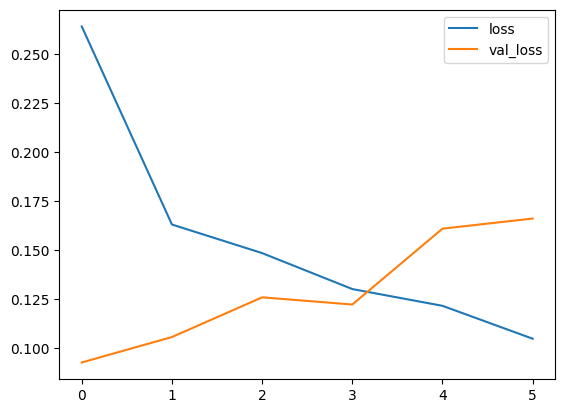

In [22]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes,
    'shared_recurrent_sizes' : [4]*2,
    'shared_dense_sizes': [32]*2,
    'task_sizes': [32]*2,
    'recurrent_type': 'ln_lstm',
    'dense_activation': 'relu',
    'dense_kernel_initializer': 'he_normal',
    'bias_initializers' : None,
    'loss_weights' : None
}

hps = {
    'lr': 1e-3,
    'l2': 0.5,
    'dropout': 0.2
}

builder_params.update(hps)

model = build_dmq(
    **builder_params
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step


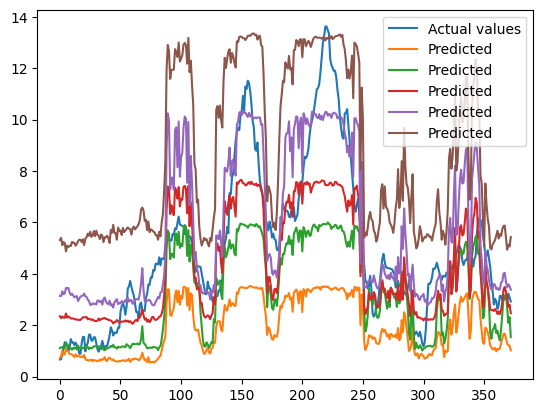

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


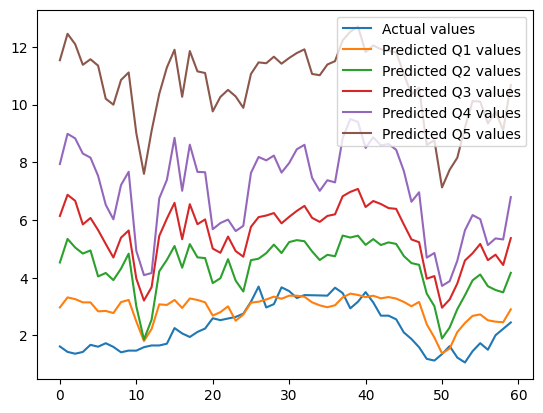

R1 for q0.05: -1050.77250838645
R1 for q0.25: -230.03999282500916
R1 for q0.5: -133.65787098285318
R1 for q0.75: -42.12487153708422
R1 for q0.95: 2.611158959936455
Mean R1: -290.796816954292
R2 score: -168.6076398038826


In [23]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

# DMQ

## Overfit

In [11]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 1, 
    'n_shared_layers': 1, 
    'n_qtask_layers': 1, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'glorot_uniform',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  None,
    'bias_initializers':  None
}

hps = {
    'l1': 0.0,
    'l2': 0.0,
    'rec_drop': 0.0,
    'lr': 1e-3
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn_full,
    mq_y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

NameError: name 'X_train_rnn' is not defined

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


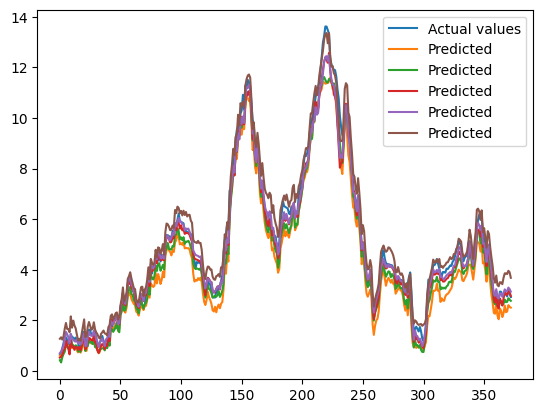

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


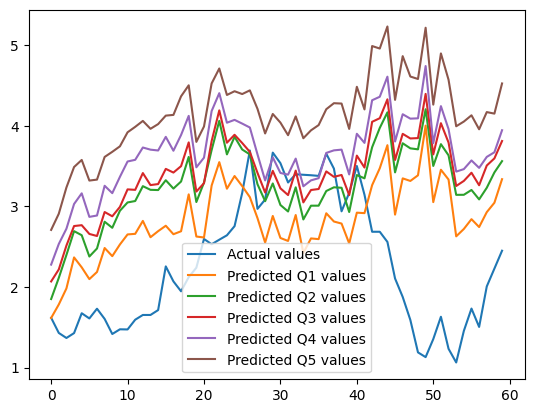

R1 for q0.05: -1089.813781505538
R1 for q0.25: -67.75978250107781
R1 for q0.5: 14.621480585794478
R1 for q0.75: 57.89848068319012
R1 for q0.95: 78.44022747030789
Mean R1: -201.32267505346462
R2 score: 61.199698338549936


In [ ]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

## Add bias initialization

In [12]:
bias_initializers = {
    q: keras.initializers.Constant(y_train.quantile(q)) for q in QUANTILES
}

Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - loss: 0.6518 - val_loss: 0.3357
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.4857 - val_loss: 0.2385
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.3350 - val_loss: 0.1766
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2359 - val_loss: 0.1158
Epoch 5/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1804 - val_loss: 0.1005
Epoch 6/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1497 - val_loss: 0.0824
Epoch 7/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1285 - val_loss: 0.0680
Epoch 8/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1095 - val_loss: 0.0643
Epoch 9/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0995 - val_loss: 0.0534
Epoch 10/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0950 - val_loss: 0.0664
Epoch 11/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0841 - val_loss: 0.0566
Epoch 12/200
109/109 ━━━━━━━━

<Axes: >

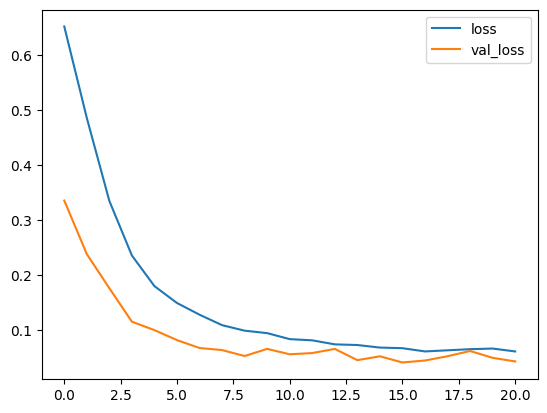

In [17]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 1, 
    'n_shared_layers': 1, 
    'n_qtask_layers': 1, 
    'n_recurrent_nodes': 4,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'glorot_uniform',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  None,
    'bias_initializers':  bias_initializers
}

hps = {
    'l1': 0.0,
    'l2': 0.0,
    'rec_drop': 0.0,
    'lr': 1e-3
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn_full,
    mq_y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step


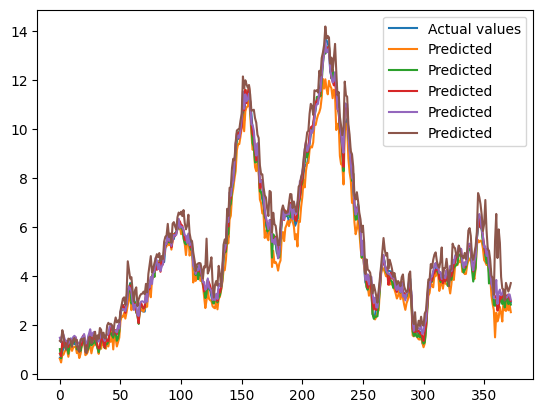

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


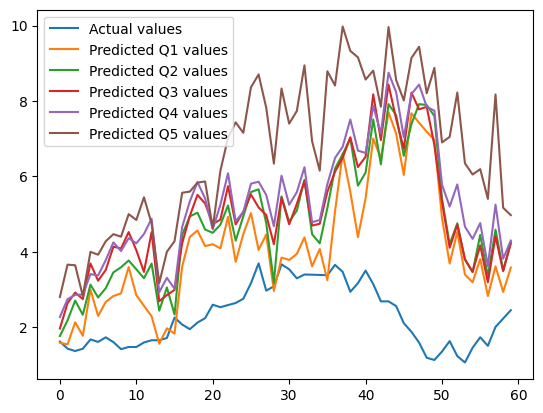

R1 for q0.05: -2922.2764783072575
R1 for q0.25: -291.7572090374158
R1 for q0.5: -93.28586211826246
R1 for q0.75: 9.932070595386266
R1 for q0.95: 50.149347566833555
Mean R1: -649.4476262601431
R2 score: -86.96294804040019


In [18]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

## Add l2 penalty

Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - loss: 0.8714 - val_loss: 0.5284
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5982 - val_loss: 0.4144
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4733 - val_loss: 0.3599
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4130 - val_loss: 0.3150
Epoch 5/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3656 - val_loss: 0.3060
Epoch 6/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3391 - val_loss: 0.2731
Epoch 7/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3065 - val_loss: 0.2451
Epoch 8/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2867 - val_loss: 0.2303
Epoch 9/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2775 - val_loss: 0.2214
Epoch 10/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2558 - val_loss: 0.2212
Epoch 11/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2393 - val_loss: 0.1903
Epoch 12/200
109/109 ━━━━━━━━

<Axes: >

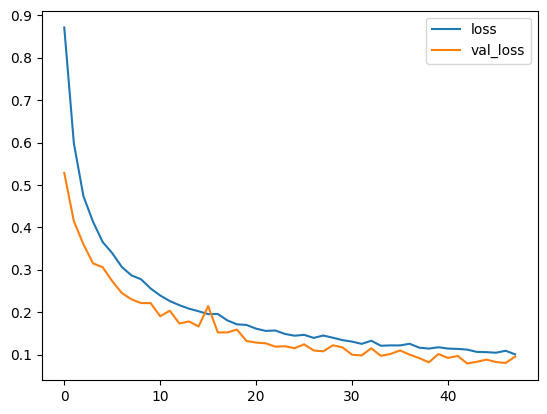

In [15]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 1, 
    'n_shared_layers': 1, 
    'n_qtask_layers': 1, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'glorot_uniform',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  None,
    'bias_initializers':  bias_initializers
}

hps = {
    'l1': 0.0,
    'l2': 1e-3,
    'rec_drop': 0.0,
    'lr': 1e-3
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn_full,
    mq_y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step


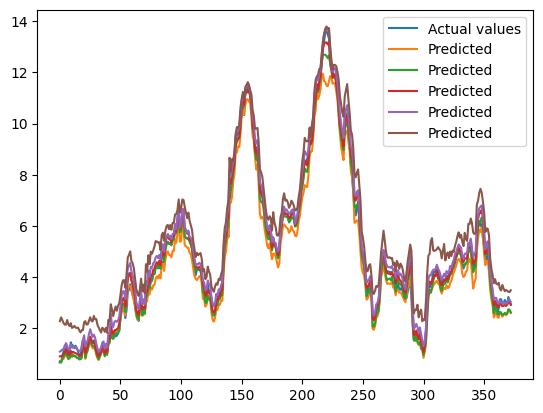

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


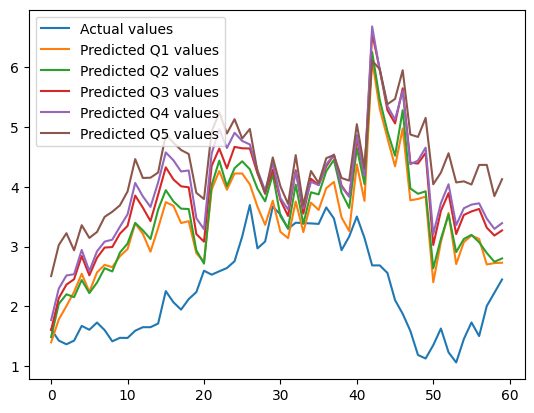

R1 for q0.05: -1769.7779190086908
R1 for q0.25: -102.76462907416727
R1 for q0.5: -14.306646898376263
R1 for q0.75: 49.05509469521539
R1 for q0.95: 76.4966774997567
Mean R1: -352.25948455725245
R2 score: 42.30592436484682


In [16]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)